# How Couples Met: Structured Analysis

This notebook reorganizes the original `clean_how_they_met.ipynb` into a cleaner, top-to-bottom workflow.
The goal is to preserve the same analysis while making the notebook easier to read, rerun, and present.

## 1. Setup

We start by importing the libraries used for data preparation, clustering, and visualization, then load the survey data.

In [188]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

df = pd.read_stata("../../data/HCMST 2017 to 2022 small public version 2.2.dta").copy()

/tmp/ipykernel_55240/1236531211.py:9: UnicodeWarning: 
One or more strings in the dta file could not be decoded using utf-8, and
so the fallback encoding of latin-1 is being used.  This can happen when a file
has been incorrectly encoded by Stata or some other software. You should verify
the string values returned are correct.
  df = pd.read_stata("../../data/HCMST 2017 to 2022 small public version 2.2.dta").copy()


## 2. Build Meeting-Type Features

The original survey contains multiple binary indicators describing how a couple met.
We group them into three broader relationship channels: social, work-based, and online.

In [189]:
social_cols = [
    "w1_q24_met_through_friend",
    "w1_q24_met_through_family",
    "w1_q24_met_through_as_nghbrs"
]

work_cols = [
    "w1_q24_met_as_through_cowork",
    "w1_q24_customer",
    "w1_q24_work_neighbors",
    "w1_q24_business_trip"
]

internet_cols = [
    "w1_q24_internet_dating",
    "w1_q24_internet_soc_network",
    "w1_q24_internet_other"
]

all_binary_cols = social_cols + work_cols + internet_cols + ["w1_q24_met_online"]

# Convert yes/no text values into numeric indicators so they can be aggregated.
for col in all_binary_cols:
    df[col] = (
        df[col]
        .astype(str)
        .str.strip()
        .str.lower()
        .map({"yes": 1, "no": 0})
    )

In [190]:
df[all_binary_cols].dtypes

w1_q24_met_through_friend       float64
w1_q24_met_through_family       float64
w1_q24_met_through_as_nghbrs    float64
w1_q24_met_as_through_cowork    float64
w1_q24_customer                 float64
w1_q24_work_neighbors           float64
w1_q24_business_trip            float64
w1_q24_internet_dating          float64
w1_q24_internet_soc_network     float64
w1_q24_internet_other           float64
w1_q24_met_online               float64
dtype: object

In [191]:
# Collapse detailed meeting indicators into three broader categories.
df["met_social"] = (df[social_cols].sum(axis=1) > 0).astype(int)
df["met_work"] = (df[work_cols].sum(axis=1) > 0).astype(int)
df["met_online"] = (df[internet_cols].sum(axis=1) > 0).astype(int)

df["w1_ppage"] = pd.to_numeric(df["w1_ppage"], errors="coerce")
df["w1_age_when_met"] = pd.to_numeric(df["w1_age_when_met"], errors="coerce")

# Approximate how long the relationship has lasted at wave 1.
df["relationship_duration"] = df["w1_ppage"] - df["w1_age_when_met"]

In [192]:
df["met_social"]

0       0
1       1
2       0
3       0
4       1
       ..
3505    0
3506    0
3507    0
3508    0
3509    1
Name: met_social, Length: 3510, dtype: int64

## 3. Clean a Key Demographic Variable

Before clustering, we inspect and recode the same-sex couple variable so it can be used numerically.

In [193]:
[col for col in df.columns if "same" in col.lower()]

['w3_xsamesex',
 'w3_same_sex_couple',
 'w3_vaccine_same',
 'w2_same_sex_couple',
 'w1_same_sex_couple',
 'w1_same_sex_couple_gender']

In [194]:
df["w1_same_sex_couple"].value_counts(dropna=False)

w1_same_sex_couple
NOT same-sex souple    3086
same_sex_couple         308
NaN                     116
Name: count, dtype: int64

In [195]:
df["w1_same_sex_couple"] = (
    df["w1_same_sex_couple"]
    .astype(str)
    .str.strip()
    .str.lower()
    .map({
        "same_sex_couple": 1,
        "not same-sex souple": 0
    })
)

df["w1_same_sex_couple"].value_counts(dropna=False)

w1_same_sex_couple
0.0    3086
1.0     308
NaN     116
Name: count, dtype: int64

## 4. Prepare Clustering Dataset

We select the variables used for clustering, remove incomplete rows, and encode text fields into numeric form.

In [196]:
selected_cols = [
    "w1_age_when_met",
    "relationship_duration",
    "met_social",
    "met_work",
    "met_online"
]

df_cluster = df[selected_cols].dropna().copy()

In [197]:
"""df_cluster["w1_married"] = (
    df_cluster["w1_married"]
    .astype(str)
    .str.lower()
    .str.strip()
    .map({"yes": 1, "no": 0})
)

df_cluster = pd.get_dummies(df_cluster, drop_first=True)

bool_cols = df_cluster.select_dtypes("bool").columns
df_cluster[bool_cols] = df_cluster[bool_cols].astype(int)"""

'df_cluster["w1_married"] = (\n    df_cluster["w1_married"]\n    .astype(str)\n    .str.lower()\n    .str.strip()\n    .map({"yes": 1, "no": 0})\n)\n\ndf_cluster = pd.get_dummies(df_cluster, drop_first=True)\n\nbool_cols = df_cluster.select_dtypes("bool").columns\ndf_cluster[bool_cols] = df_cluster[bool_cols].astype(int)'

## 5. Run K-Means Clustering

The clustering step groups similar relationships based on how the couple met and a few contextual variables.

In [198]:
# Standardize the feature space before K-means so variables are comparable.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_cluster)

kmeans = KMeans(n_clusters=3, random_state=42)
df_cluster["cluster"] = kmeans.fit_predict(X_scaled)

In [199]:
# Check the average meeting type within each cluster to interpret the groups.
df_cluster.groupby("cluster")[["met_social", "met_work", "met_online"]].mean()

,met_social,met_work,met_online
cluster,,,
0,0.217335,1.000000,0.0
1,0.484466,0.000000,0.0
2,0.092219,0.011527,1.0


## 6. Map Cluster Labels Back to the Full Dataset

Cluster assignments exist only for complete cases used in the model, so we merge them back into the main dataframe by index.

In [200]:
df["cluster"] = np.nan
df.loc[df_cluster.index, "cluster"] = df_cluster["cluster"]

In [201]:
"""cluster_names = {
    0: "Work-based relationships",
    1: "Online-initiated relationships",
    2: "Socially-initiated relationships"
}

df_cluster["cluster_name"] = df_cluster["cluster"].map(cluster_names)
df["cluster_name"] = df["cluster"].map(cluster_names)"""

'cluster_names = {\n    0: "Work-based relationships",\n    1: "Online-initiated relationships",\n    2: "Socially-initiated relationships"\n}\n\ndf_cluster["cluster_name"] = df_cluster["cluster"].map(cluster_names)\ndf["cluster_name"] = df["cluster"].map(cluster_names)'

## 7. Describe the Clusters

These summaries help us understand how the clusters differ in meeting channel and demographic structure.

In [202]:
df.groupby("cluster")["w1_same_sex_couple"].mean() * 100

cluster
0.0     5.950841
1.0     7.744259
2.0    25.072046
Name: w1_same_sex_couple, dtype: float64

In [203]:
df.groupby("w1_same_sex_couple")[["met_social", "met_work", "met_online"]].mean() * 100

,met_social,met_work,met_online
w1_same_sex_couple,,,
0.0,38.885288,23.979261,8.554763
1.0,28.571429,15.259740,28.246753


In [204]:
df_cluster.groupby("cluster").mean(numeric_only=True)

,w1_age_when_met,relationship_duration,met_social,met_work,met_online
cluster,,,,,
0,28.657179,23.615783,0.217335,1.000000,0.0
1,24.747862,25.085097,0.484466,0.000000,0.0
2,34.363113,6.077810,0.092219,0.011527,1.0


In [205]:
df_cluster.groupby("cluster")[["met_social", "met_work", "met_online"]].mean()

,met_social,met_work,met_online
cluster,,,
0,0.217335,1.000000,0.0
1,0.484466,0.000000,0.0
2,0.092219,0.011527,1.0


In [206]:
cols = [
    "w1_age_when_met",
    "met_social",
    "met_work",
    "met_online"
]

df_cluster.groupby("cluster")[cols].mean()

,w1_age_when_met,met_social,met_work,met_online
cluster,,,,
0,28.657179,0.217335,1.000000,0.0
1,24.747862,0.484466,0.000000,0.0
2,34.363113,0.092219,0.011527,1.0


## 8. Visualize Clusters with PCA

A two-dimensional PCA projection gives a rough visual sense of how separated the clusters are in the standardized feature space.

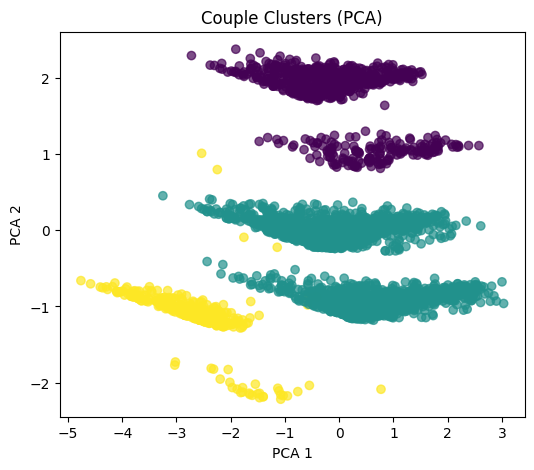

In [207]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(6, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=df_cluster["cluster"], alpha=0.7)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Couple Clusters (PCA)")
plt.show()

## 9. Analyze Relationship Stability

Now that cluster labels are available in the main dataframe, we can compare breakup and still-together outcomes across relationship types.

In [208]:
[col for col in df.columns if "w3" in col.lower() and "break" in col.lower()]

['w3_who_breakup',
 'w3_women_wanted_breakup',
 'w3_partner_type_for_het_breakups',
 'w3_breakup_year',
 'w3_breakup_month',
 'w3_breakup_source']

In [209]:
df["w3_breakup_year"].value_counts(dropna=False)

w3_breakup_year
NaN       3428
2021.0      34
2020.0      22
2022.0      13
2018.0       6
2017.0       4
1998.0       1
2000.0       1
2019.0       1
Name: count, dtype: int64

In [210]:
df["w3_breakup_source"].value_counts(dropna=False)

w3_breakup_source
NaN          3401
2017 wave      69
2020 wave      33
2022 wave       7
Name: count, dtype: int64

In [211]:
# A missing breakup source at wave 3 is treated here as still together.
df["still_together_w3"] = df["w3_breakup_source"].isna().astype(int)

df.groupby("cluster")["still_together_w3"].mean()

cluster
0.0    0.976714
1.0    0.968933
2.0    0.939481
Name: still_together_w3, dtype: float64

“All relationship types show high survival rates, though work-based relationships appear slightly more stable. However, these results should be interpreted cautiously due to high levels of missing data at wave 3.”

In [212]:
df.groupby("cluster")["still_together_w3"].value_counts()

cluster  still_together_w3
0.0      1                     755
         0                      18
1.0      1                    2152
         0                      69
2.0      1                     326
         0                      21
Name: count, dtype: int64

In [213]:
df.groupby("cluster")["still_together_w3"].value_counts(normalize=True) * 100

cluster  still_together_w3
0.0      1                    97.671410
         0                     2.328590
1.0      1                    96.893291
         0                     3.106709
2.0      1                    93.948127
         0                     6.051873
Name: proportion, dtype: float64

In [214]:
df.groupby(["w1_same_sex_couple", "cluster"])["still_together_w3"].mean()

w1_same_sex_couple  cluster
0.0                 0.0        0.975241
                    1.0        0.969253
                    2.0        0.938462
1.0                 0.0        1.000000
                    1.0        0.965116
                    2.0        0.942529
Name: still_together_w3, dtype: float64

“While same-sex couples are more likely to meet online, relationship stability appears broadly similar across couple types within each meeting context.”

In [215]:
df.groupby(["w1_same_sex_couple", "cluster"])["still_together_w3"].agg(["mean", "count"])

mean  count
w1_same_sex_couple cluster                 
0.0                0.0      0.975241    727
                   1.0      0.969253   2049
                   2.0      0.938462    260
1.0                0.0      1.000000     46
                   1.0      0.965116    172
                   2.0      0.942529     87

“No breakups were observed in this small subgroup (n=46), so this estimate is not reliable”

In [216]:
pd.crosstab(df["cluster"], df["still_together_w3"], normalize="index") * 100

still_together_w3,0,1
cluster,,
0.0,2.328590,97.671410
1.0,3.106709,96.893291
2.0,6.051873,93.948127


## 10. Wave 2 Follow-Up Checks

This final section reproduces the later-breakup checks from the original notebook using wave 2 breakup information.

In [217]:
[col for col in df.columns if "w2" in col.lower() and "break" in col.lower()]

['w2_who_breakup_combo',
 'w2_breakup_year',
 'w2_breakup_month',
 'w2_covid_breakup',
 'w2_breakup_month_tm',
 'w2_women_wanted_breakup',
 'w2_partner_type_for_het_breakups']

In [218]:
df["w2_covid_breakup"].value_counts(dropna=False)

w2_covid_breakup
NaN    3476
no       30
yes       4
Name: count, dtype: int64

In [219]:
df["w2_breakup_year"].value_counts(dropna=False)

w2_breakup_year
NaN       3320
2017.0      55
2018.0      52
2019.0      47
2020.0      34
2014.0       1
2016.0       1
Name: count, dtype: int64

In [220]:
df["still_together_w2"] = df["w2_breakup_year"].isna().astype(int)
df.groupby("cluster")["still_together_w2"].value_counts(normalize=True) * 100

cluster  still_together_w2
0.0      1                    95.213454
         0                     4.786546
1.0      1                    94.777127
         0                     5.222873
2.0      1                    89.337176
         0                    10.662824
Name: proportion, dtype: float64

“Socially initiated relationships show approximately double the breakup rate compared to work-based and online relationships at wave 2.”

In [221]:
pd.crosstab(df["cluster"], df["still_together_w2"], normalize="index") * 100

still_together_w2,0,1
cluster,,
0.0,4.786546,95.213454
1.0,5.222873,94.777127
2.0,10.662824,89.337176


“At wave 2, online-initiated relationships show the highest observed breakup rate (~10.7%), followed by socially initiated (~5.2%) and work-based relationships (~4.8%). This suggests that meeting context may be associated with relationship stability, though the results remain observational.”

“These results are based on observed breakup reports and may still be affected by missing data.”

In [222]:
df.groupby(["w1_same_sex_couple", "cluster"])["still_together_w2"].mean()

w1_same_sex_couple  cluster
0.0                 0.0        0.954608
                    1.0        0.950708
                    2.0        0.907692
1.0                 0.0        0.913043
                    1.0        0.912791
                    2.0        0.850575
Name: still_together_w2, dtype: float64

## Conclusion 

“At wave 2, online-initiated relationships show the lowest stability for both heterosexual (~90.8%) and same-sex couples (~85.1%), while work-based and socially initiated relationships exhibit higher and similar stability levels. Across all meeting contexts, same-sex couples display slightly lower stability compared to heterosexual couples, although these differences should be interpreted cautiously due to smaller sample sizes.”

## 11. Adjusted Prediction of Wave 3 Relationship Survival

We now move from descriptive comparisons to an adjusted model. The goal is to test whether Wave 1 meeting context still predicts Wave 3 relationship survival after accounting for whether the relationship had already survived to Wave 2 and a few baseline couple characteristics.


In [223]:
print(df["w1_same_sex_couple"].value_counts(dropna=False))
print(df["w1_married"].value_counts(dropna=False))
print(df["cluster"].value_counts(dropna=False))

w1_same_sex_couple
0.0    3086
1.0     308
NaN     116
Name: count, dtype: int64
w1_married
yes    2079
no     1315
NaN     116
Name: count, dtype: int64
cluster
1.0    2221
0.0     773
2.0     347
NaN     169
Name: count, dtype: int64


In [224]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

analysis_cols = [
    "still_together_w3",    # Y target
    "still_together_w2",    # Z control 
    "cluster",              # X main variable (how they met)
    "w1_married",           # Z control
    "w1_same_sex_couple",   # research variable
    "w1_partner_yrsed",     # Z control 
]

model_df = df[analysis_cols].copy()

model_df["w1_married_num"] = model_df["w1_married"].map({
    "yes": 1,
    "no": 0
})

model_df = model_df.dropna(subset=[
    "still_together_w3",
    "still_together_w2",
    "cluster",
    "w1_married_num",
    "w1_same_sex_couple",
    "w1_partner_yrsed",
]).copy()

logit_model = smf.logit(
    "still_together_w3 ~ C(cluster) + still_together_w2 + w1_married_num + w1_same_sex_couple + w1_partner_yrsed",
    data=model_df
).fit(disp=False)

or_table = pd.DataFrame({
    "odds_ratio": np.exp(logit_model.params),
    "ci_lower": np.exp(logit_model.conf_int()[0]),
    "ci_upper": np.exp(logit_model.conf_int()[1]),
    "p_value": logit_model.pvalues
}).round(3)

display(pd.DataFrame({"n_used": [len(model_df)]}))
display(or_table)


,n_used
0,3333


,odds_ratio,ci_lower,ci_upper,p_value
Intercept,19.175,5.401,68.079,0.000
C(cluster)[T.1.0],0.772,0.454,1.313,0.340
C(cluster)[T.2.0],0.491,0.250,0.964,0.039
w1_married_num[T.1],1.602,1.044,2.458,0.031
still_together_w2,4.774,2.905,7.845,0.000
w1_same_sex_couple,1.404,0.717,2.748,0.322
w1_partner_yrsed,0.936,0.864,1.014,0.105


“After controlling for wave 2 survival, marital status, couple type, and partner education, online-initiated relationships show significantly lower odds of long-term survival compared to work-based relationships. Socially initiated relationships do not differ significantly from work-based relationships. While same-sex couples appeared less stable in descriptive analysis, this effect is not statistically significant when controlling for other factors, suggesting that differences may be explained by underlying characteristics rather than couple type itself.”

In [225]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

# -----------------------------
# 0) Make sure cluster names exist
# -----------------------------
# Based on your cluster profile:
# 0 = Work, 1 = Social, 2 = Online

cluster_names = {
    0.0: "Work-based relationships",
    1.0: "Socially-initiated relationships",
    2.0: "Online-initiated relationships"
}

df["cluster_name"] = df["cluster"].map(cluster_names)

# -----------------------------
# 1) Prepare data
# -----------------------------
analysis_cols = [
    "still_together_w3",
    "still_together_w2",
    "cluster_name",
    "w1_married",
    "w1_same_sex_couple",
    "w1_partner_yrsed",
]

model_df = df[analysis_cols].copy()

model_df["w1_married_num"] = model_df["w1_married"].map({
    "yes": 1,
    "no": 0
})

# Set explicit reference category
cluster_ref = "Online-initiated relationships"

# -----------------------------
# 2) Model A: without Wave 2
# -----------------------------
model_a_df = model_df.dropna(subset=[
    "still_together_w3",
    "cluster_name",
    "w1_married_num",
    "w1_same_sex_couple",
    "w1_partner_yrsed",
]).copy()

logit_a = smf.logit(
    f"still_together_w3 ~ C(cluster_name, Treatment(reference='{cluster_ref}')) + "
    "w1_married_num + w1_same_sex_couple + w1_partner_yrsed",
    data=model_a_df
).fit(disp=False)

or_table_a = pd.DataFrame({
    "odds_ratio": np.exp(logit_a.params),
    "ci_lower": np.exp(logit_a.conf_int()[0]),
    "ci_upper": np.exp(logit_a.conf_int()[1]),
    "p_value": logit_a.pvalues
}).round(3)

# -----------------------------
# 3) Model B: with Wave 2
# -----------------------------
model_b_df = model_df.dropna(subset=[
    "still_together_w3",
    "still_together_w2",
    "cluster_name",
    "w1_married_num",
    "w1_same_sex_couple",
    "w1_partner_yrsed",
]).copy()

logit_b = smf.logit(
    f"still_together_w3 ~ C(cluster_name, Treatment(reference='{cluster_ref}')) + "
    "still_together_w2 + w1_married_num + w1_same_sex_couple + w1_partner_yrsed",
    data=model_b_df
).fit(disp=False)

or_table_b = pd.DataFrame({
    "odds_ratio": np.exp(logit_b.params),
    "ci_lower": np.exp(logit_b.conf_int()[0]),
    "ci_upper": np.exp(logit_b.conf_int()[1]),
    "p_value": logit_b.pvalues
}).round(3)

# -----------------------------
# 4) Display results
# -----------------------------
display(pd.DataFrame({
    "model": ["Model A: no W2", "Model B: with W2"],
    "n_used": [len(model_a_df), len(model_b_df)]
}))

print("MODEL A: predicts long-term survival from baseline variables only")
display(or_table_a)

print("MODEL B: predicts long-term survival while controlling for Wave 2 survival")
display(or_table_b)

print("Model A summary")
print(logit_a.summary())

print("\nModel B summary")
print(logit_b.summary())

,model,n_used
0,Model A: no W2,3333
1,Model B: with W2,3333


MODEL A: predicts long-term survival from baseline variables only


,odds_ratio,ci_lower,ci_upper,p_value
Intercept,29.997,8.817,102.059,0.000
"C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Socially-initiated relationships]",1.667,0.985,2.823,0.057
"C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Work-based relationships]",2.178,1.120,4.235,0.022
w1_married_num[T.1],1.983,1.313,2.994,0.001
w1_same_sex_couple,1.339,0.690,2.597,0.388
w1_partner_yrsed,0.940,0.869,1.016,0.120


MODEL B: predicts long-term survival while controlling for Wave 2 survival


,odds_ratio,ci_lower,ci_upper,p_value
Intercept,9.406,2.604,33.982,0.001
"C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Socially-initiated relationships]",1.574,0.920,2.692,0.098
"C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Work-based relationships]",2.038,1.037,4.006,0.039
w1_married_num[T.1],1.602,1.044,2.458,0.031
still_together_w2,4.774,2.905,7.845,0.000
w1_same_sex_couple,1.404,0.717,2.748,0.322
w1_partner_yrsed,0.936,0.864,1.014,0.105


Model A summary
                           Logit Regression Results                           
Dep. Variable:      still_together_w3   No. Observations:                 3333
Model:                          Logit   Df Residuals:                     3327
Method:                           MLE   Df Model:                            5
Date:                Wed, 22 Apr 2026   Pseudo R-squ.:                 0.02233
Time:                        16:19:19   Log-Likelihood:                -462.65
converged:                       True   LL-Null:                       -473.22
Covariance Type:            nonrobust   LLR p-value:                 0.0007644
                                                                                                                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
In

### 1. Work vs Online

Model A:
OR = 2.18
p = 0.022 ✅

Model B:
OR = 2.04
p = 0.039 ✅

👉 Interpretation:

Work-based relationships have about 2× higher odds of long-term survival compared to online relationships — even after controlling for Wave 2 survival.

### 3. Wave 2 survival (Model B only)

OR = 4.77
p = 0.000 🔥

👉 Interpretation:

If a couple survives to Wave 2, they are ~4.8x more likely to survive to Wave 3

👉 This is expected — and VERY strong

In [226]:
print("Model A sample size:", len(model_a_df))


Model A sample size: 3333


In [227]:
print("Model B sample size:", len(model_b_df))

Model B sample size: 3333


In [228]:
print("Original dataset:", len(df))


Original dataset: 3510


In [229]:
df["w2_breakup_year"].value_counts(dropna=False)

w2_breakup_year
NaN       3320
2017.0      55
2018.0      52
2019.0      47
2020.0      34
2014.0       1
2016.0       1
Name: count, dtype: int64

In [230]:
df["still_together_w3"].value_counts(dropna=False)

still_together_w3
1    3401
0     109
Name: count, dtype: int64

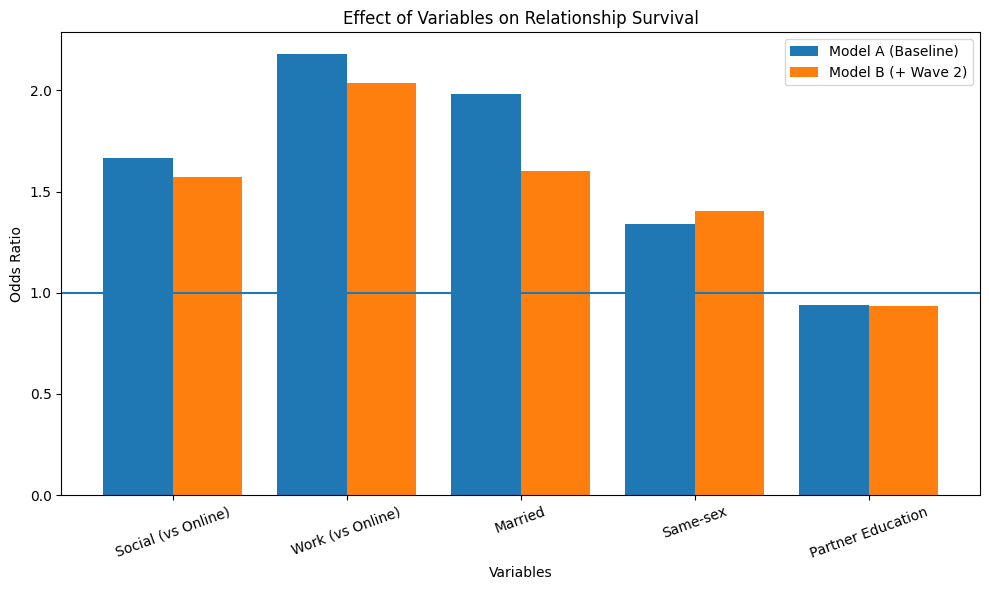

In [231]:
import matplotlib.pyplot as plt

# Copy tables
plot_a = or_table_a.copy()
plot_b = or_table_b.copy()

rename_dict = {
    "C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Socially-initiated relationships]": "Social (vs Online)",
    "C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Work-based relationships]": "Work (vs Online)",
    "w1_married_num[T.1]": "Married",
    "w1_same_sex_couple": "Same-sex",
    "w1_partner_yrsed": "Partner Education",
}

plot_a = plot_a.rename(index=rename_dict)
plot_b = plot_b.rename(index=rename_dict)

# Remove intercept (not useful visually)
plot_a = plot_a.drop("Intercept")
plot_b = plot_b.drop("Intercept")

# Align index (same variables)
common_vars = plot_a.index.intersection(plot_b.index)

plot_a = plot_a.loc[common_vars]
plot_b = plot_b.loc[common_vars]

# Create figure
plt.figure(figsize=(10,6))

x = range(len(plot_a.index))

plt.bar([i - 0.2 for i in x], plot_a["odds_ratio"], width=0.4, label="Model A (Baseline)")
plt.bar([i + 0.2 for i in x], plot_b["odds_ratio"], width=0.4, label="Model B (+ Wave 2)")

plt.xticks(x, plot_a.index, rotation=20)
plt.axhline(y=1)

plt.title("Effect of Variables on Relationship Survival")
plt.ylabel("Odds Ratio")
plt.xlabel("Variables")

plt.legend()
plt.tight_layout()
plt.show()

This companion table converts the fitted model into predicted probabilities for each meeting-profile cluster, holding the control variables at typical reference values. That makes the adjusted comparison easier to read than raw log-odds.


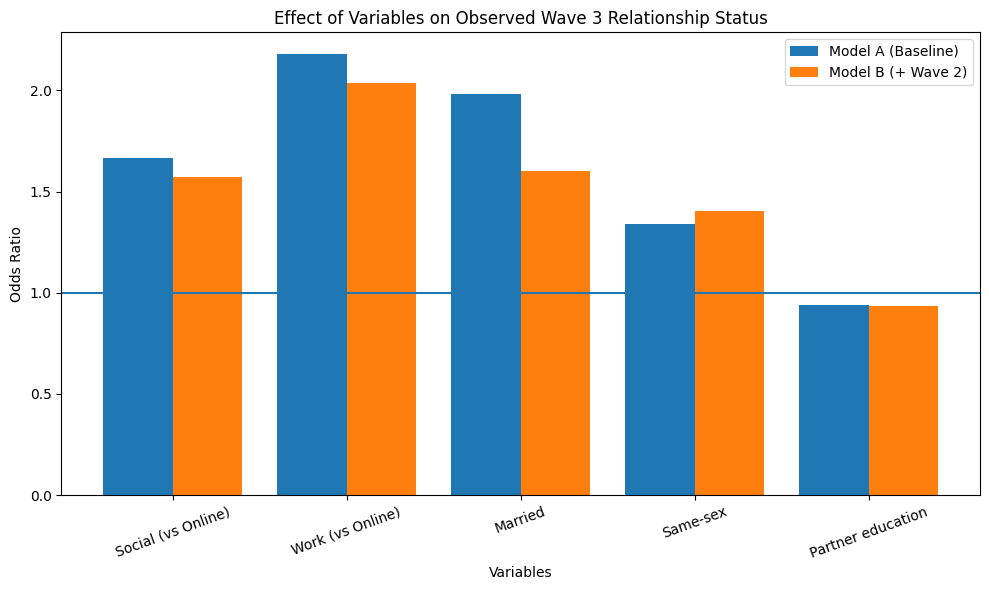

In [232]:
import matplotlib.pyplot as plt

# Copy tables
plot_a = or_table_a.copy()
plot_b = or_table_b.copy()

rename_dict = {
    "C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Socially-initiated relationships]": "Social (vs Online)",
    "C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Work-based relationships]": "Work (vs Online)",
    "w1_married_num[T.1]": "Married",
    "w1_same_sex_couple": "Same-sex",
    "w1_partner_yrsed": "Partner education",
}

plot_a = plot_a.rename(index=rename_dict)
plot_b = plot_b.rename(index=rename_dict)

# Remove intercept
plot_a = plot_a.drop("Intercept")
plot_b = plot_b.drop("Intercept")

# Align variables
common_vars = plot_a.index.intersection(plot_b.index)
plot_a = plot_a.loc[common_vars]
plot_b = plot_b.loc[common_vars]

# Plot
plt.figure(figsize=(10, 6))

x = range(len(plot_a.index))

plt.bar([i - 0.2 for i in x], plot_a["odds_ratio"], width=0.4, label="Model A (Baseline)")
plt.bar([i + 0.2 for i in x], plot_b["odds_ratio"], width=0.4, label="Model B (+ Wave 2)")

plt.xticks(x, plot_a.index, rotation=20)
plt.axhline(y=1)

plt.title("Effect of Variables on Observed Wave 3 Relationship Status")
plt.ylabel("Odds Ratio")
plt.xlabel("Variables")

plt.legend()
plt.tight_layout()
plt.show()

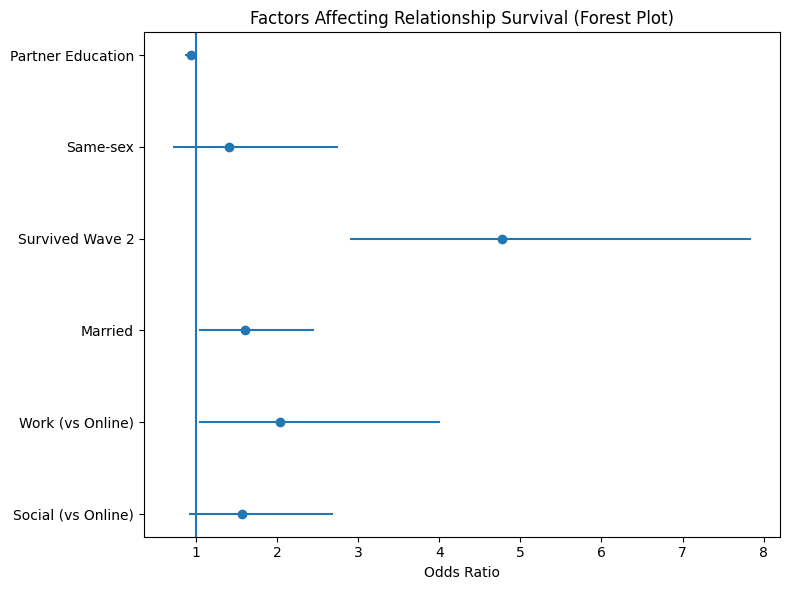

In [233]:
import matplotlib.pyplot as plt

# Use Model B (more interesting)
plot_df = or_table_b.copy()

rename_dict = {
    "C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Socially-initiated relationships]": "Social (vs Online)",
    "C(cluster_name, Treatment(reference='Online-initiated relationships'))[T.Work-based relationships]": "Work (vs Online)",
    "w1_married_num[T.1]": "Married",
    "w1_same_sex_couple": "Same-sex",
    "w1_partner_yrsed": "Partner Education",
    "still_together_w2": "Survived Wave 2"
}

plot_df = plot_df.rename(index=rename_dict)
plot_df = plot_df.drop("Intercept")

# Plot
plt.figure(figsize=(8,6))

y_pos = range(len(plot_df))

plt.errorbar(
    plot_df["odds_ratio"],
    y_pos,
    xerr=[
        plot_df["odds_ratio"] - plot_df["ci_lower"],
        plot_df["ci_upper"] - plot_df["odds_ratio"]
    ],
    fmt='o'
)

plt.yticks(y_pos, plot_df.index)
plt.axvline(x=1)  # reference line

plt.xlabel("Odds Ratio")
plt.title("Factors Affecting Relationship Survival (Forest Plot)")
plt.tight_layout()
plt.show()

In [237]:
def weighted_distribution(frame, group_col, weight_col):
    temp = frame[[group_col, weight_col]].dropna().copy()
    out = temp.groupby(group_col, observed=False)[weight_col].sum()
    return out / out.sum()

def weighted_mean_by_group(frame, group_col, value_col, weight_col):
    temp = frame[[group_col, value_col, weight_col]].dropna().copy()
    return temp.groupby(group_col, observed=False).apply(
        lambda x: np.average(x[value_col], weights=x[weight_col]),
        include_groups=False
    )

composition_compare = pd.DataFrame({
    "Unweighted sample %": (df["w1_same_sex_couple"].value_counts(normalize=True) * 100).round(2),
    "Weighted population % (w1_weight_combo)": (weighted_distribution(df, "w1_same_sex_couple", "w1_weight_combo") * 100).round(2)
}).rename(index={0.0: "Different-sex couples", 1.0: "Same-sex couples"})

weighted_cluster_distribution = (
    weighted_distribution(df, "cluster_name", "w1_weight_combo")
    .mul(100)
    .round(2)
    .rename("Weighted wave 1 share %")
)

weighted_w2_stability = (
    weighted_mean_by_group(df, "cluster_name", "still_together_w2", "w2_combo_weight")
    .mul(100)
    .round(2)
    .rename("Weighted still together at wave 2 %")
)

weighted_w3_stability = (
    weighted_mean_by_group(df, "cluster_name", "still_together_w3", "w3_combo_weight")
    .mul(100)
    .round(2)
    .rename("Weighted still together at wave 3 %")
)

summary_tables = pd.concat(
    [weighted_cluster_distribution, weighted_w2_stability, weighted_w3_stability],
    axis=1
)

display(composition_compare)
display(summary_tables)

,Unweighted sample %,Weighted population % (w1_weight_combo)
w1_same_sex_couple,,
Different-sex couples,90.93,97.459999
Same-sex couples,9.07,2.540000


,Weighted wave 1 share %,Weighted still together at wave 2 %,Weighted still together at wave 3 %
cluster_name,,,
Online-initiated relationships,8.850000,85.49,86.52
Socially-initiated relationships,67.919998,88.72,92.88
Work-based relationships,23.230000,91.85,95.80


The figure below makes the weighting adjustment easier to read visually. The left panel shows how the raw analytic sample overrepresents same-sex couples relative to the weighted Wave 1 population estimate. The right panel summarizes the weighted cluster composition and the weighted stability estimates at waves 2 and 3.

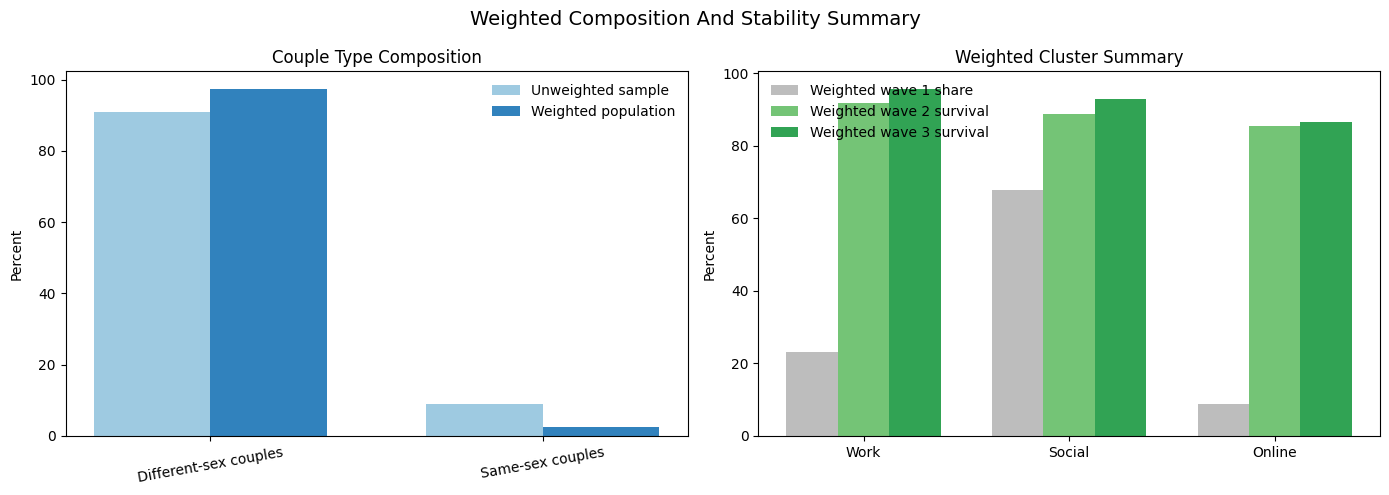

In [238]:
plot_composition = composition_compare.loc[["Different-sex couples", "Same-sex couples"]]
plot_stability = summary_tables.loc[[
    "Work-based relationships",
    "Socially-initiated relationships",
    "Online-initiated relationships"
]]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: unweighted vs weighted couple-type composition
x_left = np.arange(len(plot_composition.index))
width_left = 0.35

axes[0].bar(
    x_left - width_left / 2,
    plot_composition["Unweighted sample %"],
    width=width_left,
    label="Unweighted sample",
    color="#9ecae1"
)
axes[0].bar(
    x_left + width_left / 2,
    plot_composition["Weighted population % (w1_weight_combo)"],
    width=width_left,
    label="Weighted population",
    color="#3182bd"
)
axes[0].set_xticks(x_left)
axes[0].set_xticklabels(plot_composition.index, rotation=10)
axes[0].set_ylabel("Percent")
axes[0].set_title("Couple Type Composition")
axes[0].legend(frameon=False)

# Right panel: weighted cluster share and weighted stability
x_right = np.arange(len(plot_stability.index))
width_right = 0.25

axes[1].bar(
    x_right - width_right,
    plot_stability["Weighted wave 1 share %"],
    width=width_right,
    label="Weighted wave 1 share",
    color="#bdbdbd"
)
axes[1].bar(
    x_right,
    plot_stability["Weighted still together at wave 2 %"],
    width=width_right,
    label="Weighted wave 2 survival",
    color="#74c476"
)
axes[1].bar(
    x_right + width_right,
    plot_stability["Weighted still together at wave 3 %"],
    width=width_right,
    label="Weighted wave 3 survival",
    color="#31a354"
)
axes[1].set_xticks(x_right)
axes[1].set_xticklabels(["Work", "Social", "Online"])
axes[1].set_ylabel("Percent")
axes[1].set_title("Weighted Cluster Summary")
axes[1].legend(frameon=False)

fig.suptitle("Weighted Composition And Stability Summary", fontsize=14)
plt.tight_layout()
plt.show()

“Work-based relationships consistently exhibit the highest observed stability, followed by socially initiated relationships, while online-initiated relationships show the lowest stability. This pattern is consistent across both wave 2 and wave 3, although wave 3 estimates should be interpreted with caution due to sample attrition.”

## 12. Summary

Three relationship clusters were identified from the Wave 1 meeting features: work-based, socially initiated, and online-initiated relationships.

The clustering itself is still based on the observed sample, but the descriptive population summaries below use the survey weights so that the composition and stability estimates better reflect the target population.

This weighting matters for couple-type interpretation: the unweighted analytic sample contains about 9.1% same-sex couples, while the weighted Wave 1 population estimate is about 2.5% same-sex couples and 97.5% different-sex couples. That means any statement about how common same-sex couples are should rely on the weighted estimate rather than the raw sample share.

Using the Wave 1 weight, the estimated population distribution of the three clusters is roughly 67.9% socially initiated, 23.2% work-based, and 8.9% online-initiated. Using the appropriate follow-up weights, the weighted stability pattern remains ordered in the same direction at both later waves: work-based relationships look most stable, socially initiated relationships are in the middle, and online-initiated relationships look least stable.

In the weighted descriptive results, estimated Wave 2 survival is about 91.9% for work-based relationships, 88.7% for socially initiated relationships, and 85.5% for online-initiated relationships. At Wave 3, the weighted observed survival rates are about 95.8%, 92.9%, and 86.5% respectively. These comparisons are still observational, and the Wave 3 outcome remains especially sensitive to missing follow-up information, but the weighted summaries support the same broad conclusion: meeting context is associated with later relationship stability, and online-initiated relationships appear less stable than the other two groups.